In [1]:
import sys
print("Python:", sys.version)

packages = [
    "qiskit",
    "qiskit_nature",
    "qiskit_algorithms",
    "qiskit_aer",
    "qiskit_ibm_runtime",
    "pyscf",
    "numpy",
    "scipy",
    "pandas",
    "matplotlib",
]

for pkg in packages:
    try:
        mod = __import__(pkg)
        version = getattr(mod, "__version__", "version unavailable")
        print(f"{pkg:22s} OK   {version}")
    except Exception as e:
        print(f"{pkg:22s} MISSING/ERROR -> {e}")

Python: 3.12.3 (main, Jun 19 2026, 12:46:00) [GCC 13.3.0]
qiskit                 OK   2.5.1
qiskit_nature          MISSING/ERROR -> No module named 'qiskit_nature'
qiskit_algorithms      MISSING/ERROR -> No module named 'qiskit_algorithms'
qiskit_aer             OK   0.17.2
qiskit_ibm_runtime     OK   0.48.0
pyscf                  OK   2.14.0
numpy                  OK   2.5.1
scipy                  OK   1.18.0
pandas                 OK   3.0.5
matplotlib             OK   3.11.1


In [2]:
from qiskit import __version__ as qiskit_version

print("Active Python executable:")
print(sys.executable)

print("\nQiskit environment:")
print(qiskit_version)

Active Python executable:
/home/mudassar/qgss2026-lab3/.venv/bin/python

Qiskit environment:
2.5.1


In [3]:
%pip install qiskit-nature==0.8.0 qiskit-algorithms==0.4.0

  Using cached qiskit_algorithms-0.4.0-py3-none-any.whl.metadata (4.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 677.5 kB/s  0:00:03 eta 0:00:01
Using cached qiskit_algorithms-0.4.0-py3-none-any.whl (327 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [qiskit-nature]0m [qiskit-nature]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /home/mudassar/qgss2026-lab3/.venv/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import sys
import qiskit
import qiskit_nature
import qiskit_algorithms
import qiskit_aer
import qiskit_ibm_runtime
import pyscf

print("Python executable :", sys.executable)
print("Qiskit            :", qiskit.__version__)
print("Qiskit Nature     :", qiskit_nature.__version__)
print("Qiskit Algorithms :", qiskit_algorithms.__version__)
print("Qiskit Aer        :", qiskit_aer.__version__)
print("IBM Runtime       :", qiskit_ibm_runtime.__version__)
print("PySCF             :", pyscf.__version__)

Python executable : /home/mudassar/qgss2026-lab3/.venv/bin/python
Qiskit            : 2.5.1
Qiskit Nature     : 0.8.0
Qiskit Algorithms : 0.4.0
Qiskit Aer        : 0.17.2
IBM Runtime       : 0.48.0
PySCF             : 2.14.0


In [4]:
## imports and constants

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyscf import gto, scf, mcscf, fci

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper

from qiskit_algorithms import NumPyEigensolver
from qiskit_nature.second_q.algorithms import ExcitedStatesEigensolver

HARTREE_TO_EV = 27.211386245988

print("Scientific stack loaded successfully.")

Scientific stack loaded successfully.


In [5]:
## construct equilibrium and 90° twisted ethylene

define the $C=C$ axis along $(x)$.

In [6]:
R_CC = 1.339   # Angstrom
R_CH = 1.087   # Angstrom
HCC_ANGLE = np.deg2rad(121.3)

def build_ethylene_geometry(twist_deg=0.0):
    """
    Ethylene geometry with right CH2 group rotated around the C=C bond.
    twist_deg = 0   -> planar equilibrium-like geometry
    twist_deg = 90  -> orthogonal / twisted geometry
    """

    c1 = np.array([-R_CC/2, 0.0, 0.0])
    c2 = np.array([+R_CC/2, 0.0, 0.0])

    dx = R_CH * (-np.cos(HCC_ANGLE))
    dy = R_CH * np.sin(HCC_ANGLE)

    # left CH2 remains in xy plane
    h1 = c1 + np.array([-dx, +dy, 0.0])
    h2 = c1 + np.array([-dx, -dy, 0.0])

    # right CH2 initially in xy plane
    theta = np.deg2rad(twist_deg)

    y1 = +dy * np.cos(theta)
    z1 = +dy * np.sin(theta)

    y2 = -dy * np.cos(theta)
    z2 = -dy * np.sin(theta)

    h3 = c2 + np.array([+dx, y1, z1])
    h4 = c2 + np.array([+dx, y2, z2])

    atoms = [
        ("C", c1),
        ("C", c2),
        ("H", h1),
        ("H", h2),
        ("H", h3),
        ("H", h4),
    ]

    return atoms


eq_geom = build_ethylene_geometry(0.0)
tw90_geom = build_ethylene_geometry(90.0)

for name, geom in [("Equilibrium", eq_geom), ("Twisted 90°", tw90_geom)]:
    print("\n", name)
    for atom, xyz in geom:
        print(f"{atom:2s} {xyz[0]: .6f} {xyz[1]: .6f} {xyz[2]: .6f}")


 Equilibrium
C  -0.669500  0.000000  0.000000
C   0.669500  0.000000  0.000000
H  -1.234217  0.928797  0.000000
H  -1.234217 -0.928797  0.000000
H   1.234217  0.928797  0.000000
H   1.234217 -0.928797  0.000000

 Twisted 90°
C  -0.669500  0.000000  0.000000
C   0.669500  0.000000  0.000000
H  -1.234217  0.928797  0.000000
H  -1.234217 -0.928797  0.000000
H   1.234217  0.000000  0.928797
H   1.234217 -0.000000 -0.928797


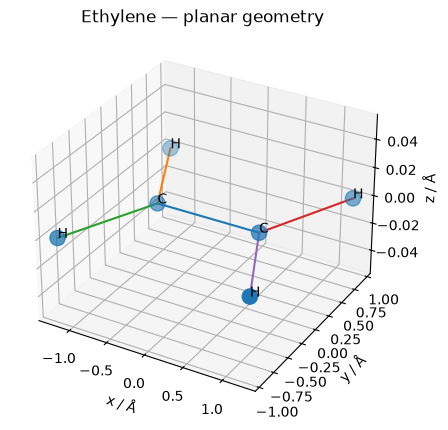

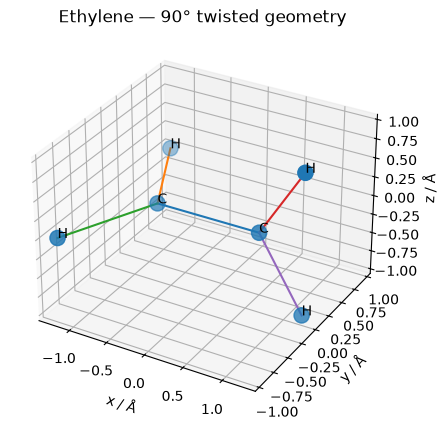

In [7]:
##  quick geometry visualization

from mpl_toolkits.mplot3d import Axes3D

def plot_geometry(geom, title):
    fig = plt.figure(figsize=(6,5))
    ax = fig.add_subplot(111, projection="3d")

    coords = np.array([xyz for _, xyz in geom])
    labels = [a for a, _ in geom]

    ax.scatter(coords[:,0], coords[:,1], coords[:,2], s=120)

    # bonds
    bonds = [(0,1),(0,2),(0,3),(1,4),(1,5)]

    for i,j in bonds:
        ax.plot(
            [coords[i,0], coords[j,0]],
            [coords[i,1], coords[j,1]],
            [coords[i,2], coords[j,2]],
        )

    for i, label in enumerate(labels):
        ax.text(coords[i,0], coords[i,1], coords[i,2], label)

    ax.set_xlabel("x / Å")
    ax.set_ylabel("y / Å")
    ax.set_zlabel("z / Å")
    ax.set_title(title)

    plt.show()

plot_geometry(eq_geom, "Ethylene — planar geometry")
plot_geometry(tw90_geom, "Ethylene — 90° twisted geometry")

In [8]:
## helper to convert geometry into PySCF/Qiskit format

def geometry_to_atom_string(geom):
    return "; ".join(
        f"{atom} {xyz[0]} {xyz[1]} {xyz[2]}"
        for atom, xyz in geom
    )

eq_atom_string = geometry_to_atom_string(eq_geom)
tw90_atom_string = geometry_to_atom_string(tw90_geom)

print(eq_atom_string)

C -0.6695 0.0 0.0; C 0.6695 0.0 0.0; H -1.2342172746130267 0.9287967483543615 0.0; H -1.2342172746130267 -0.9287967483543615 0.0; H 1.2342172746130267 0.9287967483543615 0.0; H 1.2342172746130267 -0.9287967483543615 0.0


In [9]:
## RHF + orbital inspection(This identifies the frontier orbitals before we freeze the active space.)

def run_rhf(geom, label):
    mol = gto.M(
        atom=geometry_to_atom_string(geom),
        basis="sto-3g",
        charge=0,
        spin=0,
        unit="Angstrom",
        verbose=0,
    )

    mf = scf.RHF(mol)
    mf.conv_tol = 1e-12
    mf.max_cycle = 200
    mf.kernel()

    if not mf.converged:
        print("RHF did not converge normally; trying Newton solver...")
        mf = mf.newton()
        mf.kernel()

    nocc = mol.nelectron // 2
    homo = nocc - 1
    lumo = nocc

    print("\n" + "="*70)
    print(label)
    print("="*70)
    print("Electrons:", mol.nelectron)
    print("Spatial orbitals:", mf.mo_coeff.shape[1])
    print("Nuclear repulsion:", mol.energy_nuc())
    print("RHF total energy:", mf.e_tot)
    print("HOMO index:", homo)
    print("LUMO index:", lumo)

    print("\nFrontier orbital energies:")
    for i in range(max(0,homo-2), min(len(mf.mo_energy),lumo+3)):
        tag = ""
        if i == homo:
            tag = "<-- HOMO / expected π"
        elif i == lumo:
            tag = "<-- LUMO / expected π*"

        print(f"MO {i:2d}: {mf.mo_energy[i]: .8f} Ha  {tag}")

    return mol, mf


mol_eq, mf_eq = run_rhf(eq_geom, "PLANAR ETHYLENE")
mol_tw, mf_tw = run_rhf(tw90_geom, "90° TWISTED ETHYLENE")


PLANAR ETHYLENE
Electrons: 16
Spatial orbitals: 14
Nuclear repulsion: 33.24792556492045
RHF total energy: -77.0720902154782
HOMO index: 7
LUMO index: 8

Frontier orbital energies:
MO  5: -0.52829390 Ha  
MO  6: -0.46200589 Ha  
MO  7: -0.32304104 Ha  <-- HOMO / expected π
MO  8:  0.31749873 Ha  <-- LUMO / expected π*
MO  9:  0.62900954 Ha  
MO 10:  0.68650250 Ha  

90° TWISTED ETHYLENE
Electrons: 16
Spatial orbitals: 14
Nuclear repulsion: 33.23359033052325
RHF total energy: -76.79745577881539
HOMO index: 7
LUMO index: 8

Frontier orbital energies:
MO  5: -0.49749369 Ha  
MO  6: -0.45394809 Ha  
MO  7: -0.11761950 Ha  <-- HOMO / expected π
MO  8:  0.11144912 Ha  <-- LUMO / expected π*
MO  9:  0.59482275 Ha  
MO 10:  0.71380768 Ha  


In [10]:
## inspect carbon p-orbital character(We want evidence that the HOMO/LUMO are the expected frontier π-type orbitals.)

def inspect_frontier_character(mol, mf, label):
    labels = mol.ao_labels()

    nocc = mol.nelectron // 2
    homo = nocc - 1
    lumo = nocc

    carbon_p_indices = [
        i for i, lab in enumerate(labels)
        if "C" in lab and ("2px" in lab or "2py" in lab or "2pz" in lab)
    ]

    print("\n" + "="*70)
    print(label)
    print("="*70)

    for mo_idx, name in [(homo, "HOMO"), (lumo, "LUMO")]:
        print(f"\n{name} = MO {mo_idx}")

        contributions = []

        for ao_idx in carbon_p_indices:
            coeff = mf.mo_coeff[ao_idx, mo_idx]
            contributions.append(
                (abs(coeff), labels[ao_idx], coeff)
            )

        for _, ao_label, coeff in sorted(contributions, reverse=True):
            print(f"{ao_label:25s} coefficient = {coeff:+.6f}")


inspect_frontier_character(mol_eq, mf_eq, "PLANAR FRONTIER ORBITALS")
inspect_frontier_character(mol_tw, mf_tw, "TWISTED FRONTIER ORBITALS")


PLANAR FRONTIER ORBITALS

HOMO = MO 7
0 C 2pz                   coefficient = +0.635593
1 C 2pz                   coefficient = +0.635593
1 C 2py                   coefficient = +0.000000
0 C 2py                   coefficient = -0.000000
1 C 2px                   coefficient = -0.000000
0 C 2px                   coefficient = +0.000000

LUMO = MO 8
1 C 2pz                   coefficient = +0.809877
0 C 2pz                   coefficient = -0.809877
0 C 2px                   coefficient = -0.000000
1 C 2px                   coefficient = +0.000000
0 C 2py                   coefficient = -0.000000
1 C 2py                   coefficient = +0.000000

TWISTED FRONTIER ORBITALS

HOMO = MO 7
0 C 2pz                   coefficient = +0.954573
1 C 2pz                   coefficient = +0.039490
1 C 2py                   coefficient = +0.000000
0 C 2py                   coefficient = -0.000000
1 C 2px                   coefficient = +0.000000
0 C 2px                   coefficient = +0.000000

LUMO = 

In [11]:
## CASCI(2e,2o) singlet spectrum((We use a spin-adapted singlet FCI solver, not just an unrestricted list of roots.)

def run_casci_singlets(mol, mf, label, nroots=3):
    """
    CASCI with 2 active electrons in 2 active spatial orbitals.
    Singlet roots only.
    """

    mc = mcscf.CASCI(mf, 2, 2)

    # Singlet-only solver
    singlet_solver = fci.direct_spin0.FCI(mol)
    singlet_solver.nroots = nroots

    mc.fcisolver = singlet_solver

    result = mc.kernel()

    e_tot = np.atleast_1d(mc.e_tot).astype(float)

    print("\n" + "="*70)
    print(label, " CASCI(2e,2o) SINGLET SPECTRUM")
    print("="*70)

    for i, E in enumerate(e_tot):
        gap_ev = (E - e_tot[0]) * HARTREE_TO_EV
        print(
            f"State S{i}: "
            f"E = {E:.12f} Ha | "
            f"ΔE = {gap_ev:.6f} eV"
        )

    return mc, e_tot


cas_eq, Ecas_eq = run_casci_singlets(
    mol_eq, mf_eq, "PLANAR"
)

cas_tw, Ecas_tw = run_casci_singlets(
    mol_tw, mf_tw, "TWISTED 90°"
)


PLANAR  CASCI(2e,2o) SINGLET SPECTRUM
State S0: E = -77.116592381743 Ha | ΔE = 0.000000 eV
State S1: E = -76.596402128735 Ha | ΔE = 14.155098 eV
State S2: E = -76.407032323598 Ha | ΔE = 19.308113 eV

TWISTED 90°  CASCI(2e,2o) SINGLET SPECTRUM
State S0: E = -76.913557384013 Ha | ΔE = 0.000000 eV
State S1: E = -76.797466371366 Ha | ΔE = 3.158997 eV
State S2: E = -76.571718664255 Ha | ΔE = 9.301905 eV


In [12]:
## classical benchmark table

In [13]:
classical_table = pd.DataFrame({
    "geometry": [
        "planar",
        "planar",
        "planar",
        "twisted_90",
        "twisted_90",
        "twisted_90",
    ],
    "state": [
        "S0","S1","S2",
        "S0","S1","S2",
    ],
    "energy_Ha": [
        *Ecas_eq[:3],
        *Ecas_tw[:3],
    ]
})

classical_table["excitation_eV"] = classical_table.groupby(
    "geometry"
)["energy_Ha"].transform(
    lambda x: (x-x.iloc[0])*HARTREE_TO_EV
)

classical_table

,geometry,state,energy_Ha,excitation_eV
0,planar,S0,-77.116592,0.000000
1,planar,S1,-76.596402,14.155098
2,planar,S2,-76.407032,19.308113
3,twisted_90,S0,-76.913557,0.000000
4,twisted_90,S1,-76.797466,3.158997
5,twisted_90,S2,-76.571719,9.301905


## Qiskit Nature active-space problems

Qiskit Nature `ActiveSpaceTransformer(2,2)` selects two electrons in two spatial orbitals around the Fermi level.

In [15]:
def build_qiskit_active_problem(geom, label):
    driver = PySCFDriver(
        atom=geometry_to_atom_string(geom),
        basis="sto3g",
        charge=0,
        spin=0,
        unit=DistanceUnit.ANGSTROM,
    )

    full_problem = driver.run()

    transformer = ActiveSpaceTransformer(
        num_electrons=2,
        num_spatial_orbitals=2,
    )

    active_problem = transformer.transform(full_problem)

    print("\n" + "="*70)
    print(label)
    print("="*70)

    print("Full spatial orbitals :", full_problem.num_spatial_orbitals)
    print("Full particles        :", full_problem.num_particles)

    print("Active spatial orbitals:", active_problem.num_spatial_orbitals)
    print("Active particles       :", active_problem.num_particles)

    print("Energy constants:")
    for key, value in active_problem.hamiltonian.constants.items():
        print(f"  {key}: {value}")

    return full_problem, active_problem


full_eq, qprob_eq = build_qiskit_active_problem(
    eq_geom, "QISKIT PLANAR ACTIVE SPACE"
)

full_tw, qprob_tw = build_qiskit_active_problem(
    tw90_geom, "QISKIT TWISTED ACTIVE SPACE"
)


QISKIT PLANAR ACTIVE SPACE
Full spatial orbitals : 14
Full particles        : (8, 8)
Active spatial orbitals: 2
Active particles       : (1, 1)
Energy constants:
  nuclear_repulsion_energy: 33.24792556492045
  ActiveSpaceTransformer: -109.16641399757668

QISKIT TWISTED ACTIVE SPACE
Full spatial orbitals : 14
Full particles        : (8, 8)
Active spatial orbitals: 2
Active particles       : (1, 1)
Energy constants:
  nuclear_repulsion_energy: 33.23359033052325
  ActiveSpaceTransformer: -109.26595206053324


## fermionic Hamiltonian → Jordan–Wigner qubits

`Jordan–Wigner` directly maps spin-orbital occupation to qubit occupation, which makes it the cleanest first mapper for this four-spin-orbital system.

In [16]:
jw_mapper = JordanWignerMapper()

def map_problem(problem, label):
    fermionic_hamiltonian = problem.hamiltonian.second_q_op()

    qubit_hamiltonian = jw_mapper.map(
        fermionic_hamiltonian
    )

    print("\n" + "="*70)
    print(label)
    print("="*70)

    print("Fermionic register length:",
          fermionic_hamiltonian.register_length)

    print("Qubits:",
          qubit_hamiltonian.num_qubits)

    print("Number of Pauli terms:",
          len(qubit_hamiltonian))

    print("\nFirst Pauli terms:")
    print(qubit_hamiltonian[:min(15,len(qubit_hamiltonian))])

    return fermionic_hamiltonian, qubit_hamiltonian


ferm_eq, qubit_eq = map_problem(
    qprob_eq,
    "PLANAR JORDAN-WIGNER HAMILTONIAN"
)

ferm_tw, qubit_tw = map_problem(
    qprob_tw,
    "TWISTED JORDAN-WIGNER HAMILTONIAN"
)


PLANAR JORDAN-WIGNER HAMILTONIAN
Fermionic register length: 4
Qubits: 4
Number of Pauli terms: 15

First Pauli terms:
SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IZII', 'ZIII', 'IIZZ', 'IZIZ', 'ZIIZ', 'YYYY', 'XXYY', 'YYXX', 'XXXX', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[-0.67819297+0.j,  0.07694732+0.j, -0.07819161+0.j,  0.07694732+0.j,
 -0.07819161+0.j,  0.08422202+0.j,  0.12687993+0.j,  0.12723111+0.j,
  0.0430091 +0.j,  0.0430091 +0.j,  0.0430091 +0.j,  0.0430091 +0.j,
  0.12723111+0.j,  0.13089538+0.j,  0.08422202+0.j])

TWISTED JORDAN-WIGNER HAMILTONIAN
Fermionic register length: 4
Qubits: 4
Number of Pauli terms: 27

First Pauli terms:
SparsePauliOp(['IIII', 'IIIZ', 'IIYY', 'IIXX', 'IIZI', 'IZII', 'YYII', 'XXII', 'ZIII', 'IIZZ', 'IZIZ', 'YYIZ', 'XXIZ', 'ZIIZ', 'IZYY'],
              coeffs=[-6.51480096e-01+0.j,  2.93046966e-03+0.j,  2.55022394e-07+0.j,
  2.55022394e-07+0.j,  2.62783278e-03+0.j,  2.93046966e-03+0.j,
  2.55022394e-07+0.j,  2.55022394e-07+0.j,  2.62783278e-03+

## exact physical-spectrum solver in Qiskit Nature

This is important: we do not simply diagonalize the full `16-dimensional qubit matrix` and take its smallest eigenvalues, because that includes unphysical particle-number sectors.

`Qiskit Nature` provides a physical-state filter for exactly this purpose.

In [17]:
def exact_qiskit_spectrum(problem, mapper, label):
    numpy_solver = NumPyEigensolver(
        k=16,
        filter_criterion=problem.get_default_filter_criterion()
    )

    solver = ExcitedStatesEigensolver(
        mapper,
        numpy_solver
    )

    result = solver.solve(problem)

    energies = np.real(
        np.asarray(result.total_energies, dtype=complex)
    )

    print("\n" + "="*70)
    print(label)
    print("="*70)

    for i, E in enumerate(energies[:3]):
        gap = (E - energies[0]) * HARTREE_TO_EV
        print(
            f"State {i}: "
            f"{E:.12f} Ha | "
            f"ΔE = {gap:.6f} eV"
        )

    return result, energies


exact_eq_result, Eqiskit_eq = exact_qiskit_spectrum(
    qprob_eq,
    jw_mapper,
    "PLANAR EXACT QUBIT SPECTRUM"
)

exact_tw_result, Eqiskit_tw = exact_qiskit_spectrum(
    qprob_tw,
    jw_mapper,
    "TWISTED EXACT QUBIT SPECTRUM"
)


PLANAR EXACT QUBIT SPECTRUM
State 0: -77.116592382301 Ha | ΔE = 0.000000 eV
State 1: -76.596402133189 Ha | ΔE = 14.155098 eV
State 2: -76.407032331948 Ha | ΔE = 19.308113 eV

TWISTED EXACT QUBIT SPECTRUM
State 0: -76.976929879111 Ha | ΔE = 0.000000 eV
State 1: -76.735474555739 Ha | ΔE = 6.570334 eV
State 2: -76.732915394301 Ha | ΔE = 6.639972 eV


In [18]:
## strict PySCF/Qiskit validation

In [19]:
def compare_reference(
    Ecas,
    Eqiskit,
    geometry,
    nstates=3,
    tolerance=1e-7
):
    print("\n" + "="*70)
    print(f"REFERENCE CROSS-CHECK — {geometry}")
    print("="*70)

    rows = []

    for i in range(min(
        nstates,
        len(Ecas),
        len(Eqiskit)
    )):
        diff = abs(Ecas[i] - Eqiskit[i])

        rows.append({
            "state": i,
            "CASCI_Ha": Ecas[i],
            "Qiskit_exact_Ha": Eqiskit[i],
            "abs_error_Ha": diff,
            "abs_error_eV": diff*HARTREE_TO_EV,
        })

    df = pd.DataFrame(rows)

    display(df)

    ground_ok = (
        abs(Ecas[0]-Eqiskit[0]) < tolerance
    )

    print("Ground-state match:", ground_ok)

    return df


check_eq = compare_reference(
    Ecas_eq,
    Eqiskit_eq,
    "PLANAR"
)

check_tw = compare_reference(
    Ecas_tw,
    Eqiskit_tw,
    "TWISTED 90°"
)


REFERENCE CROSS-CHECK — PLANAR


,state,CASCI_Ha,Qiskit_exact_Ha,abs_error_Ha,abs_error_eV
0,0,-77.116592,-77.116592,5.585008e-10,1.519758e-08
1,1,-76.596402,-76.596402,4.453796e-09,1.211940e-07
2,2,-76.407032,-76.407032,8.349105e-09,2.271907e-07


Ground-state match: True

REFERENCE CROSS-CHECK — TWISTED 90°


,state,CASCI_Ha,Qiskit_exact_Ha,abs_error_Ha,abs_error_eV
0,0,-76.913557,-76.976930,0.063372,1.724453
1,1,-76.797466,-76.735475,0.061992,1.686883
2,2,-76.571719,-76.732915,0.161197,4.386386


Ground-state match: False


We will explicitly identify singlet/triplet character before comparing the optical $\pi\rightarrow\pi^*$ excitation.

In [20]:
## initial physics summary


summary = pd.DataFrame({
    "Geometry": [
        "Planar",
        "Twisted 90°"
    ],

    "RHF Energy (Ha)": [
        mf_eq.e_tot,
        mf_tw.e_tot
    ],

    "CASCI S0 (Ha)": [
        Ecas_eq[0],
        Ecas_tw[0]
    ],

    "CASCI S1 gap (eV)": [
        (Ecas_eq[1]-Ecas_eq[0])*HARTREE_TO_EV,
        (Ecas_tw[1]-Ecas_tw[0])*HARTREE_TO_EV
    ],

    "CASCI S2 gap (eV)": [
        (Ecas_eq[2]-Ecas_eq[0])*HARTREE_TO_EV,
        (Ecas_tw[2]-Ecas_tw[0])*HARTREE_TO_EV
    ],

    "JW qubits": [
        qubit_eq.num_qubits,
        qubit_tw.num_qubits
    ]
})

summary

,Geometry,RHF Energy (Ha),CASCI S0 (Ha),CASCI S1 gap (eV),CASCI S2 gap (eV),JW qubits
0,Planar,-77.072090,-77.116592,14.155098,19.308113,4
1,Twisted 90°,-76.797456,-76.913557,3.158997,9.301905,4


In [22]:
## from canonical hamiltonian

from pathlib import Path

from pyscf import gto, scf, mcscf, fci

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.units import DistanceUnit

from qiskit_algorithms import NumPyEigensolver
from qiskit_nature.second_q.algorithms import ExcitedStatesEigensolver

HARTREE_TO_EV = 27.211386245988

jw_mapper = JordanWignerMapper()


def canonical_reference(geom, label):
    atom_string = geometry_to_atom_string(geom)

    # ---------------------------------------------------------
    # 1. ONE canonical RHF calculation
    # ---------------------------------------------------------
    mol = gto.M(
        atom=atom_string,
        basis="sto-3g",
        charge=0,
        spin=0,
        unit="Angstrom",
        verbose=0,
    )

    chkfile = f"ethylene_{label}_canonical.chk"

    mf = scf.RHF(mol)
    mf.chkfile = chkfile
    mf.conv_tol = 1e-12
    mf.max_cycle = 200
    mf.kernel()

    if not mf.converged:
        raise RuntimeError(f"{label}: RHF did not converge")

    nocc = mol.nelectron // 2

    # explicit HOMO/LUMO active orbitals
    active_indices = [nocc - 1, nocc]

    print("\n" + "="*78)
    print(label)
    print("="*78)

    print("RHF energy       :", mf.e_tot)
    print("HOMO index       :", active_indices[0])
    print("LUMO index       :", active_indices[1])
    print(
        "Frontier energies:",
        mf.mo_energy[active_indices[0]],
        mf.mo_energy[active_indices[1]],
    )

    # ---------------------------------------------------------
    # 2. PySCF CASCI using SAME RHF orbitals
    # ---------------------------------------------------------
    mc = mcscf.CASCI(mf, 2, 2)

    singlet_solver = fci.direct_spin0.FCI(mol)
    singlet_solver.nroots = 3
    mc.fcisolver = singlet_solver

    mc.kernel()

    cas_energies = np.atleast_1d(mc.e_tot).astype(float)

    print("\nPySCF CASCI singlets")

    for i, E in enumerate(cas_energies):
        print(
            f"S{i}: {E:.12f} Ha | "
            f"{(E-cas_energies[0])*HARTREE_TO_EV:.6f} eV"
        )

    # ---------------------------------------------------------
    # 3. Qiskit Nature reads THE SAME RHF checkpoint
    # ---------------------------------------------------------
    driver = PySCFDriver(
        atom=atom_string,
        basis="sto3g",
        charge=0,
        spin=0,
        unit=DistanceUnit.ANGSTROM,
        conv_tol=1e-12,
        max_cycle=200,
        chkfile=chkfile,
    )

    full_problem = driver.run()

    transformer = ActiveSpaceTransformer(
        num_electrons=2,
        num_spatial_orbitals=2,
        active_orbitals=active_indices,
    )

    problem = transformer.transform(full_problem)

    fermionic_hamiltonian = problem.hamiltonian.second_q_op()

    qubit_hamiltonian = jw_mapper.map(
        fermionic_hamiltonian
    )

    # ---------------------------------------------------------
    # 4. Exact Qiskit singlet spectrum
    # ---------------------------------------------------------
    numpy_solver = NumPyEigensolver(k=16)

    numpy_solver.filter_criterion = (
        problem.get_default_filter_criterion()
    )

    exact_solver = ExcitedStatesEigensolver(
        jw_mapper,
        numpy_solver,
    )

    exact_result = exact_solver.solve(problem)

    exact_energies = np.real(
        np.asarray(exact_result.total_energies)
    )

    print("\nQiskit exact physical singlets")

    for i, E in enumerate(exact_energies[:3]):
        print(
            f"S{i}: {E:.12f} Ha | "
            f"{(E-exact_energies[0])*HARTREE_TO_EV:.6f} eV"
        )

    print("\nAbsolute S0 difference:")
    print(
        abs(cas_energies[0] - exact_energies[0]),
        "Ha"
    )

    return {
        "mol": mol,
        "mf": mf,
        "mc": mc,
        "cas_energies": cas_energies,
        "full_problem": full_problem,
        "problem": problem,
        "fermionic_hamiltonian": fermionic_hamiltonian,
        "qubit_hamiltonian": qubit_hamiltonian,
        "exact_result": exact_result,
        "exact_energies": exact_energies,
        "active_indices": active_indices,
        "chkfile": chkfile,
    }


REF_EQ = canonical_reference(
    eq_geom,
    "planar"
)

REF_TW = canonical_reference(
    tw90_geom,
    "twisted90"
)


planar
RHF energy       : -77.07209021547814
HOMO index       : 7
LUMO index       : 8
Frontier energies: -0.32304103747418744 0.3174987323473052

PySCF CASCI singlets
S0: -77.116592381743 Ha | 0.000000 eV
S1: -76.596402128735 Ha | 14.155098 eV
S2: -76.407032323598 Ha | 19.308113 eV

Qiskit exact physical singlets
S0: -77.116592381743 Ha | 0.000000 eV
S1: -76.596402128735 Ha | 14.155098 eV
S2: -76.407032323598 Ha | 19.308113 eV

Absolute S0 difference:
0.0 Ha

twisted90
RHF energy       : -76.85552791065987
HOMO index       : 7
LUMO index       : 8
Frontier energies: -0.17658294653597262 0.16618394763992927

PySCF CASCI singlets
S0: -76.976929900046 Ha | 0.000000 eV
S1: -76.735474529754 Ha | 6.570335 eV
S2: -76.732915370087 Ha | 6.639974 eV

Qiskit exact physical singlets
S0: -76.976929900046 Ha | 0.000000 eV
S1: -76.735474529754 Ha | 6.570335 eV
S2: -76.732915370087 Ha | 6.639974 eV

Absolute S0 difference:
4.263256414560601e-14 Ha


In [23]:
#  replacing old  variables

mol_eq = REF_EQ["mol"]
mf_eq = REF_EQ["mf"]
Ecas_eq = REF_EQ["cas_energies"]
qprob_eq = REF_EQ["problem"]
qubit_eq = REF_EQ["qubit_hamiltonian"]
Eqiskit_eq = REF_EQ["exact_energies"]

mol_tw = REF_TW["mol"]
mf_tw = REF_TW["mf"]
Ecas_tw = REF_TW["cas_energies"]
qprob_tw = REF_TW["problem"]
qubit_tw = REF_TW["qubit_hamiltonian"]
Eqiskit_tw = REF_TW["exact_energies"]

In [24]:
## sanity    test  now 

assert mf_eq.converged
assert mf_tw.converged

assert qprob_eq.num_spatial_orbitals == 2
assert qprob_tw.num_spatial_orbitals == 2

assert sum(qprob_eq.num_particles) == 2
assert sum(qprob_tw.num_particles) == 2

assert qubit_eq.num_qubits == 4
assert qubit_tw.num_qubits == 4

assert abs(Ecas_eq[0] - Eqiskit_eq[0]) < 1e-7
assert abs(Ecas_tw[0] - Eqiskit_tw[0]) < 1e-7

print("CANONICAL CLASSICAL/QUBIT REFERENCES PASSED")

CANONICAL CLASSICAL/QUBIT REFERENCES PASSED


In [25]:
## Now Quantum  Part

In [26]:
from qiskit.primitives import StatevectorEstimator

from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP

from qiskit_nature.second_q.circuit.library import (
    HartreeFock,
    UCCSD,
)

from qiskit_nature.second_q.algorithms import (
    GroundStateEigensolver,
)

In [27]:
def run_uccsd_vqe(problem, mapper, exact_energy, label):
    history = []

    hf_state = HartreeFock(
        num_spatial_orbitals=problem.num_spatial_orbitals,
        num_particles=problem.num_particles,
        qubit_mapper=mapper,
    )

    ansatz = UCCSD(
        num_spatial_orbitals=problem.num_spatial_orbitals,
        num_particles=problem.num_particles,
        qubit_mapper=mapper,
        initial_state=hf_state,
    )

    def callback(eval_count, params, value, metadata):
        history.append(
            {
                "eval": eval_count,
                "energy": float(np.real(value)),
            }
        )

    estimator = StatevectorEstimator()

    optimizer = SLSQP(
        maxiter=300,
        ftol=1e-10,
    )

    vqe = VQE(
        estimator=estimator,
        ansatz=ansatz,
        optimizer=optimizer,
        initial_point=np.zeros(ansatz.num_parameters),
        callback=callback,
    )

    solver = GroundStateEigensolver(
        mapper,
        vqe,
    )

    result = solver.solve(problem)

    E_vqe = float(
        np.real(result.total_energies[0])
    )

    error_Ha = E_vqe - exact_energy
    error_eV = error_Ha * HARTREE_TO_EV

    print("\n" + "="*78)
    print(label, "UCCSD VQE")
    print("="*78)

    print("Exact energy :", exact_energy)
    print("VQE energy   :", E_vqe)

    print(
        "Error        :",
        error_Ha,
        "Ha =",
        error_eV,
        "eV",
    )

    print("Parameters   :", ansatz.num_parameters)
    print("Circuit depth:", ansatz.decompose().depth())
    print("Evaluations  :", len(history))

    return {
        "result": result,
        "vqe": vqe,
        "ansatz": ansatz,
        "hf": hf_state,
        "history": pd.DataFrame(history),
        "energy": E_vqe,
        "error_Ha": error_Ha,
        "error_eV": error_eV,
    }

In [28]:
VQE_EQ = run_uccsd_vqe(
    qprob_eq,
    jw_mapper,
    Eqiskit_eq[0],
    "PLANAR"
)

VQE_TW = run_uccsd_vqe(
    qprob_tw,
    jw_mapper,
    Eqiskit_tw[0],
    "TWISTED 90°"
)

/home/mudassar/qgss2026-lab3/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:653: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/mudassar/qgss2026-lab3/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:706: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)



PLANAR UCCSD VQE
Exact energy : -77.11659238174265
VQE energy   : -77.11659238174265
Error        : 0.0 Ha = 0.0 eV
Parameters   : 3
Circuit depth: 4
Evaluations  : 20

TWISTED 90° UCCSD VQE
Exact energy : -76.97692990004583
VQE energy   : -76.97692990004506
Error        : 7.673861546209082e-13 Ha = 2.0881641053213e-11 eV
Parameters   : 3
Circuit depth: 4
Evaluations  : 13


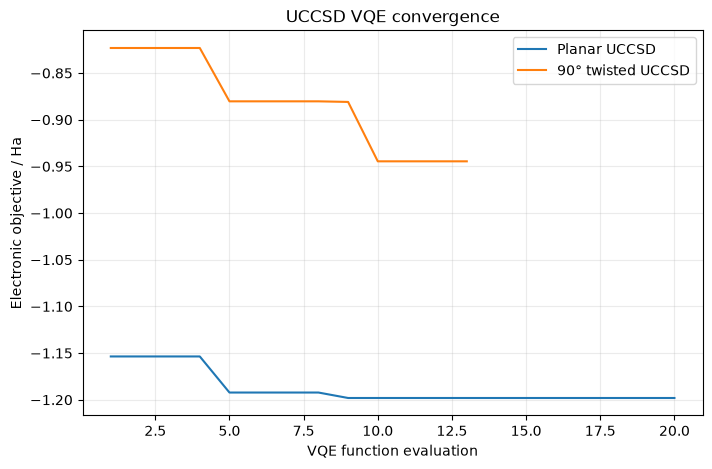

In [29]:
## VQE CONVERGENCE FIGURE

plt.figure(figsize=(8,5))

plt.plot(
    VQE_EQ["history"]["eval"],
    VQE_EQ["history"]["energy"],
    label="Planar UCCSD"
)

plt.plot(
    VQE_TW["history"]["eval"],
    VQE_TW["history"]["energy"],
    label="90° twisted UCCSD"
)

plt.xlabel("VQE function evaluation")
plt.ylabel("Electronic objective / Ha")
plt.title("UCCSD VQE convergence")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

##  HARDWARE-EFFICIENT ANSATZ BENCHMARK

Use the current function-based `efficient_su2`, which IBM documents as the preferred modern construction for the standard hardware-efficient $SU(2)$ ansatz.

In [30]:
from qiskit.circuit.library import efficient_su2

In [31]:
def run_hea_vqe(
    problem,
    qubit_hamiltonian,
    exact_total_energy,
    label,
    reps=1,
    seed=42,
):

    rng = np.random.default_rng(seed)

    hf = HartreeFock(
        problem.num_spatial_orbitals,
        problem.num_particles,
        jw_mapper,
    )

    variational = efficient_su2(
        num_qubits=qubit_hamiltonian.num_qubits,
        su2_gates=["ry", "rz"],
        entanglement="linear",
        reps=reps,
    )

    ansatz = hf.compose(
        variational
    )

    history = []

    def callback(eval_count, params, value, metadata):
        history.append(
            (eval_count, float(np.real(value)))
        )

    estimator = StatevectorEstimator()

    initial_point = rng.uniform(
        -0.05,
        0.05,
        size=ansatz.num_parameters,
    )

    vqe = VQE(
        estimator=estimator,
        ansatz=ansatz,
        optimizer=SLSQP(
            maxiter=500,
            ftol=1e-10
        ),
        initial_point=initial_point,
        callback=callback,
    )

    # VQE directly on active electronic Hamiltonian
    raw = vqe.compute_minimum_eigenvalue(
        qubit_hamiltonian
    )

    print("\n" + "="*78)
    print(label, f"HEA reps={reps}")
    print("="*78)

    print("Raw active-space eigenvalue:", raw.eigenvalue)
    print("Parameters:", ansatz.num_parameters)
    print("Depth:", ansatz.decompose().depth())

    return {
        "raw": raw,
        "vqe": vqe,
        "ansatz": ansatz,
        "history": pd.DataFrame(
            history,
            columns=["eval","energy"]
        ),
    }

In [32]:
## Comparision

HEA_EQ_1 = run_hea_vqe(
    qprob_eq,
    qubit_eq,
    Eqiskit_eq[0],
    "PLANAR",
    reps=1,
    seed=42,
)

HEA_EQ_2 = run_hea_vqe(
    qprob_eq,
    qubit_eq,
    Eqiskit_eq[0],
    "PLANAR",
    reps=2,
    seed=42,
)

HEA_TW_1 = run_hea_vqe(
    qprob_tw,
    qubit_tw,
    Eqiskit_tw[0],
    "TWISTED",
    reps=1,
    seed=42,
)


PLANAR HEA reps=1
Raw active-space eigenvalue: -1.0219864453835028
Parameters: 16
Depth: 8

PLANAR HEA reps=2
Raw active-space eigenvalue: -1.0219864305090263
Parameters: 24
Depth: 12

TWISTED HEA reps=1
Raw active-space eigenvalue: -0.9471243260441574
Parameters: 16
Depth: 8


For $CAS(2e,2o)$, the spin-orbital ordering is:

$0 = π α$;
$1 = π* α$;
$2 = π β$;
$3 = π* β$

The Hartree-Fock occupation is:

$$ |q_3q_2q_1q_0\rangle = |0101\rangle $$

under the usual `Jordan-Wigner/Qiskit ordering`.

We construct a chemically meaningful singlet subspace:

$$ O_0=I $$ $$ O_1= \frac{1}{\sqrt2} \left( a^\dagger_{1}a_0+ a^\dagger_{3}a_2 \right) $$

and a double excitation.

In [33]:
from qiskit_nature.second_q.operators import FermionicOp
from qiskit.quantum_info import Statevector
from scipy.linalg import eigh

In [34]:
def qse_operators_jw():

    single_alpha = FermionicOp(
        {"+_1 -_0": 1.0},
        num_spin_orbitals=4,
    )

    single_beta = FermionicOp(
        {"+_3 -_2": 1.0},
        num_spin_orbitals=4,
    )

    singlet_single = (
        single_alpha + single_beta
    ) / np.sqrt(2)

    double_excitation = FermionicOp(
        {
            "+_1 +_3 -_2 -_0": 1.0
        },
        num_spin_orbitals=4,
    )

    identity = FermionicOp(
        {"": 1.0},
        num_spin_orbitals=4,
    )

    fermionic_ops = [
        identity,
        singlet_single,
        double_excitation,
    ]

    qubit_ops = [
        jw_mapper.map(op)
        for op in fermionic_ops
    ]

    return fermionic_ops, qubit_ops


QSE_FERM_OPS, QSE_QUBIT_OPS = qse_operators_jw()

print("QSE subspace dimension:", len(QSE_QUBIT_OPS))

QSE subspace dimension: 3


In [35]:
##  OPTIMIZED VQE STATE

In [36]:
def get_vqe_state(vqe_bundle):

    result = vqe_bundle["result"]

    optimal_point = result.raw_result.optimal_point

    circuit = vqe_bundle[
        "ansatz"
    ].assign_parameters(
        optimal_point
    )

    state = Statevector.from_instruction(
        circuit
    )

    return circuit, state


ucc_eq_circuit, psi_eq = get_vqe_state(
    VQE_EQ
)

ucc_tw_circuit, psi_tw = get_vqe_state(
    VQE_TW
)

print("Planar state norm :", np.linalg.norm(psi_eq.data))
print("Twisted state norm:", np.linalg.norm(psi_tw.data))

Planar state norm : 1.0
Twisted state norm: 0.9999999999999999


CONSTRUCT $(H_{\rm QSE})$ AND $S
QSE$
	​

In [37]:
def manual_qse(
    state,
    qubit_hamiltonian,
    qse_ops,
    label,
):

    psi = state.data

    Hmat_full = qubit_hamiltonian.to_matrix()

    basis_vectors = []

    for op in qse_ops:
        vec = op.to_matrix() @ psi
        basis_vectors.append(vec)

    n = len(basis_vectors)

    Hqse = np.zeros(
        (n,n),
        dtype=complex
    )

    Sqse = np.zeros(
        (n,n),
        dtype=complex
    )

    for i in range(n):
        for j in range(n):

            vi = basis_vectors[i]
            vj = basis_vectors[j]

            Hqse[i,j] = (
                np.vdot(
                    vi,
                    Hmat_full @ vj
                )
            )

            Sqse[i,j] = (
                np.vdot(
                    vi,
                    vj
                )
            )

    # enforce numerical Hermiticity
    Hqse = (Hqse + Hqse.conj().T) / 2
    Sqse = (Sqse + Sqse.conj().T) / 2

    # overlap diagonalization
    svals, svecs = np.linalg.eigh(Sqse)

    keep = svals > 1e-9

    print("\n" + "="*78)
    print(label, "MANUAL QSE")
    print("="*78)

    print("Overlap eigenvalues:")
    print(svals)

    print(
        "Overlap condition number:",
        (
            np.max(svals[keep]) /
            np.min(svals[keep])
        )
    )

    # orthogonalize
    X = (
        svecs[:,keep]
        @ np.diag(
            1.0 / np.sqrt(svals[keep])
        )
    )

    H_orth = (
        X.conj().T
        @ Hqse
        @ X
    )

    energies, coeffs = np.linalg.eigh(
        H_orth
    )

    energies = np.real(energies)

    print("\nQSE raw active-space energies:")

    for i, E in enumerate(energies):
        print(
            f"QSE state {i}: "
            f"{E:.12f} Ha | "
            f"gap = {(E-energies[0])*HARTREE_TO_EV:.6f} eV"
        )

    return {
        "H": Hqse,
        "S": Sqse,
        "energies": energies,
        "overlap_eigenvalues": svals,
        "condition_number":
            np.max(svals[keep]) /
            np.min(svals[keep]),
    }

In [38]:
QSE_EQ = manual_qse(
    psi_eq,
    qubit_eq,
    QSE_QUBIT_OPS,
    "PLANAR"
)

QSE_TW = manual_qse(
    psi_tw,
    qubit_tw,
    QSE_QUBIT_OPS,
    "TWISTED 90°"
)


PLANAR MANUAL QSE
Overlap eigenvalues:
[0.72416646 0.93728203 1.21311558]
Overlap condition number: 1.675188850232982

QSE raw active-space energies:
QSE state 0: -1.198103951904 Ha | gap = 0.000000 eV
QSE state 1: -0.677913698897 Ha | gap = 14.155098 eV
QSE state 2: -0.488543893760 Ha | gap = 19.308113 eV

TWISTED 90° MANUAL QSE
Overlap eigenvalues:
[0.19278102 0.50247871 1.30969769]
Overlap condition number: 6.793706769189733

QSE raw active-space energies:
QSE state 0: -0.944568184705 Ha | gap = 0.000000 eV
QSE state 1: -0.703112814413 Ha | gap = 6.570335 eV
QSE state 2: -0.700553654747 Ha | gap = 6.639974 eV


In [39]:
## QSE BENCHMARK TABLE(Because excitation energies are energy differences, constant inactive/nuclear energy shifts cancel.)

qse_benchmark = pd.DataFrame({
    "geometry": [
        "planar",
        "twisted_90",
    ],

    "CASCI_S1_eV": [
        (Ecas_eq[1]-Ecas_eq[0])
        * HARTREE_TO_EV,

        (Ecas_tw[1]-Ecas_tw[0])
        * HARTREE_TO_EV,
    ],

    "QSE_first_gap_eV": [
        (
            QSE_EQ["energies"][1]
            - QSE_EQ["energies"][0]
        ) * HARTREE_TO_EV,

        (
            QSE_TW["energies"][1]
            - QSE_TW["energies"][0]
        ) * HARTREE_TO_EV,
    ],
})

qse_benchmark[
    "abs_error_eV"
] = abs(
    qse_benchmark["CASCI_S1_eV"]
    -
    qse_benchmark["QSE_first_gap_eV"]
)

qse_benchmark




,geometry,CASCI_S1_eV,QSE_first_gap_eV,abs_error_eV
0,planar,14.155098,14.155098,3.552714e-14
1,twisted_90,6.570335,6.570335,3.650413e-13


In [40]:
##  MASTER QUANTUM BENCHMARK

master = pd.DataFrame({
    "geometry": [
        "planar",
        "twisted_90",
    ],

    "CASCI_ground_Ha": [
        Ecas_eq[0],
        Ecas_tw[0],
    ],

    "ExactQubit_ground_Ha": [
        Eqiskit_eq[0],
        Eqiskit_tw[0],
    ],

    "UCCSD_VQE_ground_Ha": [
        VQE_EQ["energy"],
        VQE_TW["energy"],
    ],

    "VQE_error_mHa": [
        1000*(
            VQE_EQ["energy"]
            - Eqiskit_eq[0]
        ),

        1000*(
            VQE_TW["energy"]
            - Eqiskit_tw[0]
        ),
    ],

    "CASCI_S1_gap_eV": [
        (Ecas_eq[1]-Ecas_eq[0])
        * HARTREE_TO_EV,

        (Ecas_tw[1]-Ecas_tw[0])
        * HARTREE_TO_EV,
    ],

    "QSE_gap_eV": [
        (
            QSE_EQ["energies"][1]
            - QSE_EQ["energies"][0]
        )*HARTREE_TO_EV,

        (
            QSE_TW["energies"][1]
            - QSE_TW["energies"][0]
        )*HARTREE_TO_EV,
    ],
})

master

,geometry,CASCI_ground_Ha,ExactQubit_ground_Ha,UCCSD_VQE_ground_Ha,VQE_error_mHa,CASCI_S1_gap_eV,QSE_gap_eV
0,planar,-77.116592,-77.116592,-77.116592,0.000000e+00,14.155098,14.155098
1,twisted_90,-76.976930,-76.976930,-76.976930,7.673862e-10,6.570335,6.570335


In [41]:
## identifying  QSE states 

from qiskit_nature.second_q.properties import ParticleNumber, AngularMomentum
from qiskit.quantum_info import SparsePauliOp, Operator

particle_op = jw_mapper.map(
    ParticleNumber(2).second_q_ops()["ParticleNumber"]
)

s2_op = jw_mapper.map(
    AngularMomentum(2).second_q_ops()["AngularMomentum"]
)

def manual_qse_full(
    state,
    qubit_hamiltonian,
    qse_ops,
    label,
    tol=1e-9,
):
    psi = np.asarray(state.data, dtype=complex)

    H = qubit_hamiltonian.to_matrix()

    basis_vectors = [
        op.to_matrix() @ psi
        for op in qse_ops
    ]

    B = np.column_stack(basis_vectors)
    n = len(qse_ops)

    Hqse = np.zeros((n,n), dtype=complex)
    Sqse = np.zeros((n,n), dtype=complex)

    for i in range(n):
        for j in range(n):
            vi = basis_vectors[i]
            vj = basis_vectors[j]

            Hqse[i,j] = np.vdot(
                vi,
                H @ vj
            )

            Sqse[i,j] = np.vdot(
                vi,
                vj
            )

    Hqse = (Hqse + Hqse.conj().T)/2
    Sqse = (Sqse + Sqse.conj().T)/2

    svals, U = np.linalg.eigh(Sqse)
    keep = svals > tol

    X = U[:,keep] @ np.diag(
        1/np.sqrt(svals[keep])
    )

    Horth = X.conj().T @ Hqse @ X

    energies, Corth = np.linalg.eigh(Horth)

    C_original = X @ Corth

    states = []

    print("\n" + "="*75)
    print(label)
    print("="*75)

    for k in range(len(energies)):

        coeff = C_original[:,k]

        vec = B @ coeff
        vec /= np.linalg.norm(vec)

        sv = Statevector(vec)

        N = np.real(
            sv.expectation_value(particle_op)
        )

        S2 = np.real(
            sv.expectation_value(s2_op)
        )

        overlaps = []

        for b in basis_vectors:
            if np.linalg.norm(b) < 1e-12:
                overlaps.append(0.0)
            else:
                bn = b / np.linalg.norm(b)
                overlaps.append(
                    abs(np.vdot(bn, vec))**2
                )

        states.append({
            "energy": float(np.real(energies[k])),
            "statevector": sv,
            "particle_number": float(N),
            "S2": float(S2),
            "basis_overlaps": overlaps,
        })

        print(
            f"State {k}: "
            f"E={energies[k]:.10f} Ha | "
            f"gap={(energies[k]-energies[0])*HARTREE_TO_EV:.5f} eV | "
            f"<N>={N:.6f} | "
            f"<S2>={S2:.6f}"
        )

        print(
            "  overlaps [ground, singlet-single, double] =",
            np.round(overlaps,5)
        )

    return {
        "H": Hqse,
        "S": Sqse,
        "energies": np.real(energies),
        "states": states,
        "overlap_eigenvalues": svals,
    }

In [42]:
QSE_EQ_FULL = manual_qse_full(
    psi_eq,
    qubit_eq,
    QSE_QUBIT_OPS,
    "PLANAR MANUAL QSE"
)

QSE_TW_FULL = manual_qse_full(
    psi_tw,
    qubit_tw,
    QSE_QUBIT_OPS,
    "TWISTED MANUAL QSE"
)


PLANAR MANUAL QSE
State 0: E=-1.1981039519 Ha | gap=0.00000 eV | <N>=2.000000 | <S2>=0.000000
  overlaps [ground, singlet-single, double] = [1.      0.      0.06272]
State 1: E=-0.6779136989 Ha | gap=14.15510 eV | <N>=2.000000 | <S2>=0.000000
  overlaps [ground, singlet-single, double] = [0. 1. 0.]
State 2: E=-0.4885438938 Ha | gap=19.30811 eV | <N>=2.000000 | <S2>=0.000000
  overlaps [ground, singlet-single, double] = [0.      0.      0.93728]

TWISTED MANUAL QSE
State 0: E=-0.9445681847 Ha | gap=0.00000 eV | <N>=2.000000 | <S2>=0.000000
  overlaps [ground, singlet-single, double] = [1.      0.      0.49752]
State 1: E=-0.7031128144 Ha | gap=6.57034 eV | <N>=2.000000 | <S2>=0.000000
  overlaps [ground, singlet-single, double] = [0. 1. 0.]
State 2: E=-0.7005536547 Ha | gap=6.63997 eV | <N>=2.000000 | <S2>=0.000000
  overlaps [ground, singlet-single, double] = [0.      0.      0.50248]


In [43]:
##  Cross-check with Qiskit QEOM

from qiskit_nature.second_q.algorithms import (
    QEOM,
    EvaluationRule
)

def run_qeom(problem, mapper, label):

    estimator = StatevectorEstimator()

    hf = HartreeFock(
        problem.num_spatial_orbitals,
        problem.num_particles,
        mapper,
    )

    ansatz = UCCSD(
        problem.num_spatial_orbitals,
        problem.num_particles,
        mapper,
        initial_state=hf,
    )

    vqe = VQE(
        estimator,
        ansatz,
        SLSQP(maxiter=300),
    )

    vqe.initial_point = np.zeros(
        ansatz.num_parameters
    )

    gse = GroundStateEigensolver(
        mapper,
        vqe
    )

    qeom = QEOM(
        gse,
        estimator,
        excitations="sd",
        aux_eval_rules=EvaluationRule.ALL,
    )

    result = qeom.solve(problem)

    print("\n" + "="*75)
    print(label)
    print("="*75)

    print("Total energies:")
    for i,E in enumerate(result.total_energies):
        gap = (
            E-result.total_energies[0]
        )*HARTREE_TO_EV

        print(
            f"{i}: {E:.10f} Ha | "
            f"gap={gap:.5f} eV"
        )

    print("\nQEOM excitation energies:")
    print(
        np.asarray(
            result.raw_result.excitation_energies
        )*HARTREE_TO_EV
    )

    return result


In [44]:
QEOM_EQ = run_qeom(
    qprob_eq,
    jw_mapper,
    "PLANAR QEOM"
)

QEOM_TW = run_qeom(
    qprob_tw,
    jw_mapper,
    "TWISTED QEOM"
)

/home/mudassar/qgss2026-lab3/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:653: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/mudassar/qgss2026-lab3/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:706: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)



PLANAR QEOM
Total energies:
0: -77.1165923816 Ha | gap=0.00000 eV
1: -76.9404695209 Ha | gap=4.79255 eV
2: -76.5963967559 Ha | gap=14.15524 eV
3: -76.4070269507 Ha | gap=19.30826 eV

QEOM excitation energies:
[ 4.79254719 14.1552441  19.30825901]

TWISTED QEOM
Total energies:
0: -76.9769299000 Ha | gap=0.00000 eV
1: -76.9744630503 Ha | gap=0.06713 eV
2: -76.7353867988 Ha | gap=6.57272 eV
3: -76.7328276387 Ha | gap=6.64236 eV

QEOM excitation energies:
[0.0671264  6.57272262 6.64236092]


In [45]:
## Produce the central benchmark table
benchmark = pd.DataFrame({
    "Geometry": [
        "Planar",
        "Twisted 90°"
    ],

    "Exact ground / Ha": [
        Eqiskit_eq[0],
        Eqiskit_tw[0]
    ],

    "UCCSD VQE / Ha": [
        VQE_EQ["energy"],
        VQE_TW["energy"]
    ],

    "VQE error / mHa": [
        1000*(VQE_EQ["energy"]-Eqiskit_eq[0]),
        1000*(VQE_TW["energy"]-Eqiskit_tw[0])
    ],

    "CASCI S1 / eV": [
        (Ecas_eq[1]-Ecas_eq[0])*HARTREE_TO_EV,
        (Ecas_tw[1]-Ecas_tw[0])*HARTREE_TO_EV
    ],

    "Manual QSE S1 / eV": [
        (
            QSE_EQ_FULL["energies"][1]
            -
            QSE_EQ_FULL["energies"][0]
        )*HARTREE_TO_EV,

        (
            QSE_TW_FULL["energies"][1]
            -
            QSE_TW_FULL["energies"][0]
        )*HARTREE_TO_EV
    ],
})

benchmark

,Geometry,Exact ground / Ha,UCCSD VQE / Ha,VQE error / mHa,CASCI S1 / eV,Manual QSE S1 / eV
0,Planar,-77.116592,-77.116592,0.000000e+00,14.155098,14.155098
1,Twisted 90°,-76.976930,-76.976930,7.673862e-10,6.570335,6.570335


## Build a 2-qubit NISQ version with parity mapping

For real hardware, we should not automatically use four Jordan-Wigner qubits.

The scientifically clean workflow is:

JW 4-qubit model = primary transparent benchmark

and

Parity-reduced 2-qubit model = NISQ hardware experiment

Qiskit Nature supports particle-aware parity reduction.

In [46]:
from qiskit_nature.second_q.mappers import ParityMapper

def make_parity_mapper(problem):
    return ParityMapper(
        num_particles=problem.num_particles
    )

parity_eq = make_parity_mapper(qprob_eq)
parity_tw = make_parity_mapper(qprob_tw)

H2_EQ = parity_eq.map(
    qprob_eq.hamiltonian.second_q_op()
)

H2_TW = parity_tw.map(
    qprob_tw.hamiltonian.second_q_op()
)

print("Planar parity qubits :", H2_EQ.num_qubits)
print("Twisted parity qubits:", H2_TW.num_qubits)

print("\nPlanar reduced Hamiltonian:")
print(H2_EQ)

Planar parity qubits : 2
Twisted parity qubits: 2

Planar reduced Hamiltonian:
SparsePauliOp(['II', 'IZ', 'ZI', 'ZZ', 'XX'],
              coeffs=[-0.846637  +0.j,  0.15513893+0.j, -0.15513893+0.j, -0.00331308+0.j,
  0.17203638+0.j])


In [47]:
## Optimize the 2-qubit hardware state locally


def run_parity_vqe(problem, mapper, label):

    hf = HartreeFock(
        problem.num_spatial_orbitals,
        problem.num_particles,
        mapper,
    )

    ansatz = UCCSD(
        problem.num_spatial_orbitals,
        problem.num_particles,
        mapper,
        initial_state=hf,
    )

    estimator = StatevectorEstimator()

    vqe = VQE(
        estimator=estimator,
        ansatz=ansatz,
        optimizer=SLSQP(
            maxiter=300,
            ftol=1e-10,
        ),
        initial_point=np.zeros(
            ansatz.num_parameters
        )
    )

    solver = GroundStateEigensolver(
        mapper,
        vqe
    )

    result = solver.solve(problem)

    optimal_point = (
        result.raw_result.optimal_point
    )

    fixed_circuit = (
        ansatz.assign_parameters(
            optimal_point
        )
    )

    print("\n", label)
    print("Qubits :", fixed_circuit.num_qubits)
    print("Depth  :", fixed_circuit.decompose().depth())
    print("Energy :", result.total_energies[0])

    return {
        "result": result,
        "ansatz": ansatz,
        "circuit": fixed_circuit,
        "optimal_point": optimal_point,
    }

In [48]:
PARITY_EQ = run_parity_vqe(
    qprob_eq,
    parity_eq,
    "PLANAR PARITY VQE"
)

PARITY_TW = run_parity_vqe(
    qprob_tw,
    parity_tw,
    "TWISTED PARITY VQE"
)

/home/mudassar/qgss2026-lab3/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:653: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/mudassar/qgss2026-lab3/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:706: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)



 PLANAR PARITY VQE
Qubits : 2
Depth  : 4
Energy : -77.11659238174265

 TWISTED PARITY VQE
Qubits : 2
Depth  : 4
Energy : -76.97692990004506


In [49]:
## Verify the electronic-energy constant shift

def energy_constant(problem):

    vals = [
        float(np.real(v))
        for v in
        problem.hamiltonian.constants.values()
    ]

    return sum(vals)


SHIFT_EQ = energy_constant(qprob_eq)
SHIFT_TW = energy_constant(qprob_tw)

print("Planar constant shift :", SHIFT_EQ)
print("Twisted constant shift:", SHIFT_TW)


Planar constant shift : -75.9184884298386
Twisted constant shift: -76.03236171534067


In [50]:
psi2 = Statevector.from_instruction(
    PARITY_EQ["circuit"]
)

raw_active_energy = np.real(
    psi2.expectation_value(H2_EQ)
)

reconstructed_total = (
    raw_active_energy + SHIFT_EQ
)

print("Raw active energy   :", raw_active_energy)
print("Constant shift      :", SHIFT_EQ)
print("Reconstructed total :", reconstructed_total)
print(
    "Qiskit total        :",
    PARITY_EQ["result"].total_energies[0]
)

Raw active energy   : -1.1981039519040484
Constant shift      : -75.9184884298386
Reconstructed total : -77.11659238174265
Qiskit total        : -77.11659238174265


In [51]:
##  Connect to IBM and derive a realistic noise model